In [1]:
import sys
sys.path.append("/home/plgrid/plgmichalbrz/take_1")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from algorithms import globals
import os
import time
import Net
 
num_of_thresholds = 1000



In [3]:
def scale(x):
    a, b = globals.def_clamps
    c, d = globals.original_clamps

    x_scaled = ((x - a) / (b - a)) * (d - c) + c
    return x_scaled



In [4]:

def get_records(path):
    records = []

    if not os.path.exists(path):
        records = None
    elif path.__contains__("run_records"):
        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                help = row["error"].strip("()[]").split(",")
                row["acc"] = (1-float(help[0]))
                row["error"] = help[1]
                row["time"] = help[2]
                converted_row = {
                    key: (float(value) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)

    else:

        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                converted_row = {
                    key: (float(value) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)

    return records



In [5]:

def calculate_thresholds(algs_run_records):

    all_errors = [
        r['error']
        for records in algs_run_records.values()
        for r in records
    ]

    all_errors = np.array(all_errors)
    all_errors = all_errors[all_errors >= globals.def_smallest_val]

    percentiles = np.linspace(0, 100, num=num_of_thresholds + 1)
    thresholds = np.percentile(all_errors, percentiles)


    # min_error = np.min(all_errors)
    # max_error = np.max(all_errors)

    # min_error = max(min_error, globals.def_smallest_val)

    # # thresholds = np.linspace(min_error, max_error, num=num_of_thresholds + 1)
    # # thresholds = np.percentile(all_errors, percentiles)
    # thresholds = np.logspace(
    #     np.log10(min_error),
    #     np.log10(max_error),
    #     num=num_of_thresholds
    # )
    return thresholds

In [6]:
# def ecdf(run_records, thresholds):
#     checkpoint_run_errors = {}

#     for r in run_records:
#         chk = r['checkpoint']
# # TODO        # error = (1-r['error'])
#         error = r['error']
#         if chk not in checkpoint_run_errors:
#             checkpoint_run_errors[chk] = []
#         checkpoint_run_errors[chk].append(error)

#     avg_part_of_thresholds_reached = []
#     prev_reached = None

#     for chk in globals.def_checkpoints:
#         errors = checkpoint_run_errors.get(chk, [])
#         if not errors:
#             if prev_reached is None:
#                 avg_part_of_thresholds_reached.append(0)
#             else:
#                 avg_part_of_thresholds_reached.append(np.mean(prev_reached))
#             continue

#         fractions = []
#         for e in errors:
#             reached_now = e <= thresholds

#             if prev_reached is not None:
#                 reached_now = np.maximum(prev_reached, reached_now)

#             fractions.append(np.sum(reached_now) / len(thresholds))

#         avg_fraction = np.mean(fractions)
#         avg_part_of_thresholds_reached.append(avg_fraction)

#         combined_reached = np.zeros(len(thresholds), dtype=bool)
#         for e in errors:
#             combined_reached = np.maximum(combined_reached, e <= thresholds)

#         if prev_reached is None:
#             prev_reached = combined_reached
#         else:
#             prev_reached = np.maximum(prev_reached, combined_reached)

#     return avg_part_of_thresholds_reached



In [7]:
# import numpy as np
# from scipy import stats import ecdf

# x1 = np.array([1, 2, 4, 5])
# x2 = np.array([2, 3, 4, 6])

# ecdf1 = ecdf(x1)
# ecdf2 = ecdf(x2)

# thresholds = np.sort(np.unique(np.concatenate([x1, x2])))

# cdf1 = ecdf1.cdf.evaluate(thresholds)
# cdf2 = ecdf2.cdf.evaluate(thresholds)

# print(thresholds)
# print(cdf1)
# print(cdf2)

In [8]:
import numpy as np


def ecdf_plot(algs_run_records, ax):

    # Collect errors from ALL algorithms
    all_errors = []

    for _, run_record in algs_run_records:

        all_errors.extend(
            d["error"]
            for d in run_record
            if d["error"] >= globals.def_smallest_val
        )

    # Common thresholds for ALL algorithms
    thresholds = np.sort(np.unique(all_errors))

    y = {}

    # Calculate ECDF for each algorithm
    for algorithm_name, run_record in algs_run_records:

        y[algorithm_name] = []

        best_so_far = np.inf

        for checkpoint in globals.def_checkpoints:

            checkpoint_errors = [
                d["error"]
                for d in run_record
                if d["checkpoint"] == checkpoint
                and d["error"] >= globals.def_smallest_val
            ]

            if checkpoint_errors:

                checkpoint_min = np.min(checkpoint_errors)

                best_so_far = min(
                    best_so_far,
                    checkpoint_min
                )

            if np.isinf(best_so_far) or len(thresholds) == 0:
                frac = 0.0
            else:
                # Fraction of COMMON thresholds cleared
                frac = np.mean(thresholds >= best_so_far)

            y[algorithm_name].append(frac)

    return y

In [9]:

def compare(logs):
    checkpoints = globals.def_checkpoints

    algs_run_records = {}
    algs_records = {}
    for algorithm in logs:
        algs_records[algorithm['name']] = get_records(f"{algorithm['path']}")
        algs_run_records[algorithm['name']] = get_records(f"{algorithm['run_path']}")

        # for r in algs_run_records[algorithm['name']]:
        #     r['error'] = round(r['error'], 2)

        # for r in algs_records[algorithm['name']]:
        #     r['min'] = round(r['min'], 2)
        #     r['std'] = round(r['std'], 2)


    fig, axs = plt.subplots(2, 2, figsize=(20, 20))
    axs = axs.flatten()
    plot_idx = 0

    # ECDF
    # ecdf_thresholds = calculate_thresholds(algs_run_records)

    ax = axs[plot_idx]
    # for algorithm_name, run_record in algs_run_records.items():
    #     y = ecdf(run_record, ecdf_thresholds)
    #     ax.plot(globals.def_checkpoints, y, label=algorithm_name, marker='o')

    y = ecdf_plot(algs_run_records.items(), ax)
    i = -2
    for algorithm_name, run_record in algs_run_records.items():
        ax.plot(
            np.array(globals.def_checkpoints)  * Net.MAX_EVALS,
            y[algorithm_name],
            label=algorithm_name,
            marker="o"
        )
        i += 1
    
    ax.set_xlabel('Checkpoint (evaluations)')
    ax.set_ylabel('Fraction of thresholds reached (ECDF)')
    ax.set_title(f"learning method comparison, ECDF")
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])
    ax.grid(True)
    ax.legend()

    plot_idx += 1

    # Mean + Std
    ax = axs[plot_idx]
    i = -2
    for algorithm_name, records in algs_records.items():
        means = []
        stds = []

        for checkpoint in checkpoints:
            if records:
                mean_vals = [r['mean'] for r in records if r['checkpoint'] == checkpoint]
                std_vals = [r['std'] for r in records if r['checkpoint'] == checkpoint]
                means.append(np.mean(mean_vals) if mean_vals else 0)
                stds.append(np.mean(std_vals) if std_vals else 0)
            else:
                means.append(0)
                stds.append(0)
    
        # ax.plot(np.array(checkpoints) * Net.MAX_EVALS, means, label=algorithm_name, marker='o')
        # ax.fill_between(np.array(checkpoints) * Net.MAX_EVALS,
        #                 np.array(means) - np.array(stds),
        #                 np.array(means) + np.array(stds),
        #                 alpha=0.2)

        ax.plot(checkpoints, means, label=algorithm_name, marker='o')
        ax.fill_between(checkpoints,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.2)
        i += 1

    ax.set_xlabel('Checkpoint')
    ax.set_ylabel("Loss")
    ax.set_title(f"learning method comparison, mean and std")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

    plot_idx += 1



    #### shifted ECDF
    # ecdf checkpoint times

    checkpoint_avg_times = {}

    for algorithm_name, run_records in algs_run_records.items():

        if not run_records:
            continue

        checkpoint_avg_times[algorithm_name] = {}

        for checkpoint in globals.def_checkpoints:

            times = [
                r['time']
                for r in run_records
                if r['checkpoint'] == checkpoint
                and r['time'] is not None
                and not np.isnan(r['time'])
            ]

            if times:
                checkpoint_avg_times[algorithm_name][checkpoint] = np.mean(times)


    ax = axs[plot_idx]

    i = -2
    y = ecdf_plot(algs_run_records.items(), ax)
    for algorithm_name, run_records in algs_run_records.items():

        if not run_records:
            continue


        x = np.array([checkpoint_avg_times[algorithm_name].get(checkpoint, np.nan) for checkpoint in globals.def_checkpoints])

        ax.plot(
            x,
            y[algorithm_name],
            label=algorithm_name,
            marker='o'
        )
        i += 1
        ax.set_xlabel('Average runtime (seconds)')
        ax.set_ylabel('Fraction of thresholds reached')
        ax.set_title("ECDF vs runtime")

        ax.set_xscale('log')
        ax.set_ylim([0, 1.05])
        ax.grid(True)
        ax.legend()

    plot_idx += 1
####################
    # Mean Accuracy + Std from run records


    ax = axs[plot_idx]

    for algorithm_name, run_records in algs_run_records.items():

        if not run_records:
            continue

        means = []
        stds = []

        for checkpoint in checkpoints:

            accuracy_vals = [
                r['acc']
                for r in run_records
                if r['checkpoint'] == checkpoint
                and r['acc'] is not None
                and not np.isnan(r['acc'])
            ]

            if accuracy_vals:
                means.append(np.mean(accuracy_vals))
                stds.append(np.std(accuracy_vals))
            else:
                means.append(np.nan)
                stds.append(np.nan)

        x = np.array(checkpoints) * Net.MAX_EVALS

        means = np.array(means)
        stds = np.array(stds)

        ax.plot(
            x,
            means,
            label=algorithm_name,
            marker='o'
        )

        ax.fill_between(
            x,
            means - stds,
            means + stds,
            alpha=0.2
        )


    ax.set_xlabel('Checkpoint (evaluations)')
    ax.set_ylabel('Accuracy')
    ax.set_title('Learning method comparison, mean accuracy ± std')
    ax.set_xscale('log')
    ax.grid(True)
    ax.legend()

    plot_idx += 1







    plt.tight_layout()
    # plt.savefig(f"./charts/net/1.png", transparent=False, facecolor='white', dpi=300)

    plt.show()


In [10]:
logs = [
    # # { "name" : "adagrad_001", "path": "./Adagrad/ada_net_aclosstim_tanh_001_logs/ada_net_aclosstim_tanh_001_records.csv", "run_path": "./Adagrad/ada_net_aclosstim_tanh_001_logs/ada_net_aclosstim_tanh_001_run_records.csv"},
    # { "name" : "adagrad", "path": "./Adagrad/ada_net_aclosstim_tanh_logs/ada_net_aclosstim_tanh_records.csv", "run_path": "./Adagrad/ada_net_aclosstim_tanh_logs/ada_net_aclosstim_tanh_run_records.csv"},
    # # { "name" : "L_BFGS_B", "path": "./BFGS/bfgs_net_aclosstim_tanh_logs/bfgs_net_aclosstim_tanh_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_logs/bfgs_net_aclosstim_tanh_run_records.csv"},
    # { "name" : "L_BFGS_B", "path": "./BFGS/bfgs_net_aclosstim_tanh_2_logs/bfgs_net_aclosstim_tanh_2_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_2_logs/bfgs_net_aclosstim_tanh_2_run_records.csv"},

    # # { "name" : "adam_2", "path": "./Adam/adam_net_aclosstim_tanh_2_logs/adam_net_aclosstim_tanh_2_records.csv", "run_path": "./Adam/adam_net_aclosstim_tanh_2_logs/adam_net_aclosstim_tanh_2_run_records.csv"},

    # { "name" : "adam", "path": "./Adam/adam_net_aclosstim_tanh_logs/adam_net_aclosstim_tanh_records.csv", "run_path": "./Adam/adam_net_aclosstim_tanh_logs/adam_net_aclosstim_tanh_run_records.csv"},
    # { "name" : "cmaes_0", "path": "./CMAES/cmaes_net_aclosstim_tanh_logs/cmaes_net_aclosstim_tanh_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_logs/cmaes_net_aclosstim_tanh_run_records.csv"},
    # { "name" : "cmaes", "path": "./CMAES/cmaes_net_aclosstim_tanh_2_logs/cmaes_net_aclosstim_tanh_2_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_2_logs/cmaes_net_aclosstim_tanh_2_run_records.csv"},

    # # # { "name" : "nl_shade", "path": "./NLShade/nl_net_aclosstim_tanh_logs/nl_net_aclosstim_tanh_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_logs/nl_net_aclosstim_tanh_run_records.csv"},
    # { "name" : "nl_shade_2", "path": "./NLShade/nl_net_aclosstim_tanh_2_logs/nl_net_aclosstim_tanh_2_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_2_logs/nl_net_aclosstim_tanh_2_run_records.csv"},
    # # { "name" : "nl_shade_3", "path": "./NLShade/nl_net_aclosstim_tanh_3_logs/nl_net_aclosstim_tanh_3_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_3_logs/nl_net_aclosstim_tanh_3_run_records.csv"},
    # # { "name" : "nl_shade_4", "path": "./NLShade/nl_net_aclosstim_tanh_4_logs/nl_net_aclosstim_tanh_4_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_4_logs/nl_net_aclosstim_tanh_4_run_records.csv"},
    # # # { "name" : "nl_shade_5", "path": "./NLShade/nl_net_aclosstim_tanh_5_logs/nl_net_aclosstim_tanh_5_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_5_logs/nl_net_aclosstim_tanh_5_run_records.csv"},
    # { "name" : "nl_shade", "path": "./NLShade/nl_net_aclosstim_tanh_6_logs/nl_net_aclosstim_tanh_6_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_6_logs/nl_net_aclosstim_tanh_6_run_records.csv"},
    # # { "name" : "nl_shade_7", "path": "./NLShade/nl_net_aclosstim_tanh_7_logs/nl_net_aclosstim_tanh_7_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_7_logs/nl_net_aclosstim_tanh_7_run_records.csv"},

    # { "name" : "L_BFGS_B_unbias", "path": "./BFGS/bfgs_net_aclosstim_tanh_bias_logs/bfgs_net_aclosstim_tanh_bias_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_bias_logs/bfgs_net_aclosstim_tanh_bias_run_records.csv"},
    # { "name" : "adam_unbias", "path": "./Adam/adam_net_aclosstim_tanh_bias_logs/adam_net_aclosstim_tanh_bias_records.csv", "run_path": "./Adam/adam_net_aclosstim_tanh_bias_logs/adam_net_aclosstim_tanh_bias_run_records.csv"},
    # { "name" : "adagrad_unbias", "path": "./Adagrad/ada_net_aclosstim_tanh_bias_logs/ada_net_aclosstim_tanh_bias_records.csv", "run_path": "./Adagrad/ada_net_aclosstim_tanh_bias_logs/ada_net_aclosstim_tanh_bias_run_records.csv"},
    # { "name" : "cmaes_unbias", "path": "./CMAES/cmaes_net_aclosstim_tanh_bias_logs/cmaes_net_aclosstim_tanh_bias_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_bias_logs/cmaes_net_aclosstim_tanh_bias_run_records.csv"},
    # { "name" : "nl_shade_unbias", "path": "./NLShade/nl_net_aclosstim_tanh_bias_logs/nl_net_aclosstim_tanh_bias_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_bias_logs/nl_net_aclosstim_tanh_bias_run_records.csv"},

    # { "name" : "L_BFGS_B", "path": "./BFGS/bfgs_net_aclosstim_tanh_BB_logs/bfgs_net_aclosstim_tanh_BB_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_BB_logs/bfgs_net_aclosstim_tanh_BB_run_records.csv"},
    { "name" : "adam", "path": "./Adam/adam_net_aclosstim_tanh_BB_logs/adam_net_aclosstim_tanh_BB_records.csv", "run_path": "./Adam/adam_net_aclosstim_tanh_BB_logs/adam_net_aclosstim_tanh_BB_run_records.csv"},
    # { "name" : "adagrad", "path": "./Adagrad/ada_net_aclosstim_tanh_BB_logs/ada_net_aclosstim_tanh_BB_records.csv", "run_path": "./Adagrad/ada_net_aclosstim_tanh_BB_logs/ada_net_aclosstim_tanh_BB_run_records.csv"},
    # { "name" : "cmaes", "path": "./CMAES/cmaes_net_aclosstim_tanh_BB_logs/cmaes_net_aclosstim_tanh_BB_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_BB_logs/cmaes_net_aclosstim_tanh_BB_run_records.csv"},
    # { "name" : "nl_shade", "path": "./NLShade/nl_net_aclosstim_tanh_BB_logs/nl_net_aclosstim_tanh_BB_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_BB_logs/nl_net_aclosstim_tanh_BB_run_records.csv"},
    { "name" : "nl_shade_2", "path": "./NLShade/nl_net_aclosstim_tanh_25-2_logs/nl_net_aclosstim_tanh_25-2_records.csv", "run_path": "./NLShade/nl_net_aclosstim_tanh_25-2_logs/nl_net_aclosstim_tanh_25-2_run_records.csv"},


    # { "name" : "L_BFGS_B_S", "path": "./BFGS/bfgs_net_aclosstim_tanh_20-25_logs/bfgs_net_aclosstim_tanh_20-25_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_20-25_logs/bfgs_net_aclosstim_tanh_20-25_run_records.csv"},
    # { "name" : "cmaes_S", "path": "./CMAES/cmaes_net_aclosstim_tanh_20-25_logs/cmaes_net_aclosstim_tanh_20-25_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_20-25_logs/cmaes_net_aclosstim_tanh_20-25_run_records.csv"},
    # { "name" : "cmaes_S_2", "path": "./CMAES/cmaes_net_aclosstim_tanh_100-10_logs/cmaes_net_aclosstim_tanh_100-10_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_100-10_logs/cmaes_net_aclosstim_tanh_100-10_run_records.csv"},
    # { "name" : "cmaes_S_3", "path": "./CMAES/cmaes_net_aclosstim_tanh_50-5_logs/cmaes_net_aclosstim_tanh_50-5_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_50-5_logs/cmaes_net_aclosstim_tanh_50-5_run_records.csv"},
    { "name" : "cmaes_S_4", "path": "./CMAES/cmaes_net_aclosstim_tanh_25-2_logs/cmaes_net_aclosstim_tanh_25-2_records.csv", "run_path": "./CMAES/cmaes_net_aclosstim_tanh_25-2_logs/cmaes_net_aclosstim_tanh_25-2_run_records.csv"},
    { "name" : "L_BFGS_B_S_2", "path": "./BFGS/bfgs_net_aclosstim_tanh_25-2_logs/bfgs_net_aclosstim_tanh_25-2_records.csv", "run_path": "./BFGS/bfgs_net_aclosstim_tanh_25-2_logs/bfgs_net_aclosstim_tanh_25-2_run_records.csv"},
    # { "name" : "adagrad_2", "path": "./Adagrad/ada_net_aclosstim_tanh_2_logs/ada_net_aclosstim_tanh_2_records.csv", "run_path": "./Adagrad/ada_net_aclosstim_tanh_2_logs/ada_net_aclosstim_tanh_2_run_records.csv"},
    # { "name" : "cmaes_sig005", "path": "./CMAES/cmaes_10-10_sig005_logs/cmaes_10-10_sig005_records.csv", "run_path": "./CMAES/cmaes_10-10_sig005_logs/cmaes_10-10_sig005_run_records.csv"},
    # { "name" : "cmaes_sn_10-10", "path": "./CMAES/cmaes_10-10_sn_logs/cmaes_10-10_sn_records.csv", "run_path": "./CMAES/cmaes_10-10_sn_logs/cmaes_10-10_sn_run_records.csv"},
    # { "name" : "cmaes_sn_10-20", "path": "./CMAES/cmaes_10-20_sn_logs/cmaes_10-20_sn_records.csv", "run_path": "./CMAES/cmaes_10-20_sn_logs/cmaes_10-20_sn_run_records.csv"},


    { "name" : "adam_fair", "path": "./Adam_fair/adam_fair_logs/adam_fair_records.csv", "run_path": "./Adam_fair/adam_fair_logs/adam_fair_run_records.csv"},

]

In [11]:
logs = [
    # { "name" : "BFGS_1", "path": "./BFGS/bfgs_NEW_1_logs/bfgs_NEW_1_records.csv", "run_path": "./BFGS/bfgs_NEW_1_logs/bfgs_NEW_1_run_records.csv"},
    # { "name" : "adam_1", "path": "./Adam/adam_NEW_1_logs/adam_NEW_1_records.csv", "run_path": "./Adam/adam_NEW_1_logs/adam_NEW_1_run_records.csv"},
    # { "name" : "adagrad_1", "path": "./Adagrad/ada_NEW_1_logs/ada_NEW_1_records.csv", "run_path": "./Adagrad/ada_NEW_1_logs/ada_NEW_1_run_records.csv"},
    # { "name" : "cmaes_1", "path": "./CMAES/cmaes_NEW_1_logs/cmaes_NEW_1_records.csv", "run_path": "./CMAES/cmaes_NEW_1_logs/cmaes_NEW_1_run_records.csv"},
    # { "name" : "nl_shade_1", "path": "./NLShade/nl_NEW_1_logs/nl_NEW_1_records.csv", "run_path": "./NLShade/nl_NEW_1_logs/nl_NEW_1_run_records.csv"},

    # { "name" : "ada_fair_1", "path": "./Adagrad_fair/ada_fair_NEW_1_logs/ada_fair_NEW_1_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_1_logs/ada_fair_NEW_1_run_records.csv"},
    # { "name" : "adam_fair_1", "path": "./Adam_fair/adam_fair_NEW_1_logs/adam_fair_NEW_1_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_1_logs/adam_fair_NEW_1_run_records.csv"},

]

In [12]:
logs += [
    # { "name" : "BFGS_2", "path": "./BFGS/bfgs_NEW_2_logs/bfgs_NEW_2_records.csv", "run_path": "./BFGS/bfgs_NEW_2_logs/bfgs_NEW_2_run_records.csv"},
    # { "name" : "adam_2", "path": "./Adam/adam_NEW_2_logs/adam_NEW_2_records.csv", "run_path": "./Adam/adam_NEW_2_logs/adam_NEW_2_run_records.csv"},
    # { "name" : "adagrad_2", "path": "./Adagrad/ada_NEW_2_logs/ada_NEW_2_records.csv", "run_path": "./Adagrad/ada_NEW_2_logs/ada_NEW_2_run_records.csv"},
    # { "name" : "cmaes_2", "path": "./CMAES/cmaes_NEW_2_logs/cmaes_NEW_2_records.csv", "run_path": "./CMAES/cmaes_NEW_2_logs/cmaes_NEW_2_run_records.csv"},
    # { "name" : "nl_shade_2", "path": "./NLShade/nl_NEW_2_logs/nl_NEW_2_records.csv", "run_path": "./NLShade/nl_NEW_2_logs/nl_NEW_2_run_records.csv"},

    # { "name" : "ada_fair_2", "path": "./Adagrad_fair/ada_fair_NEW_2_logs/ada_fair_NEW_2_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_2_logs/ada_fair_NEW_2_run_records.csv"},
    # { "name" : "adam_fair_2", "path": "./Adam_fair/adam_fair_NEW_2_logs/adam_fair_NEW_2_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_2_logs/adam_fair_NEW_2_run_records.csv"},

]

In [13]:
logs += [
    # { "name" : "BFGS_3", "path": "./BFGS/bfgs_NEW_3_logs/bfgs_NEW_3_records.csv", "run_path": "./BFGS/bfgs_NEW_3_logs/bfgs_NEW_3_run_records.csv"},
    # { "name" : "adam_3", "path": "./Adam/adam_NEW_3_logs/adam_NEW_3_records.csv", "run_path": "./Adam/adam_NEW_3_logs/adam_NEW_3_run_records.csv"},
    # { "name" : "adagrad_3", "path": "./Adagrad/ada_NEW_3_logs/ada_NEW_3_records.csv", "run_path": "./Adagrad/ada_NEW_3_logs/ada_NEW_3_run_records.csv"},
    # { "name" : "cmaes_3", "path": "./CMAES/cmaes_NEW_3_logs/cmaes_NEW_3_records.csv", "run_path": "./CMAES/cmaes_NEW_3_logs/cmaes_NEW_3_run_records.csv"},
    # { "name" : "nl_shade_3", "path": "./NLShade/nl_NEW_3_logs/nl_NEW_3_records.csv", "run_path": "./NLShade/nl_NEW_3_logs/nl_NEW_3_run_records.csv"},

    # { "name" : "ada_fair_3", "path": "./Adagrad_fair/ada_fair_NEW_3_logs/ada_fair_NEW_3_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_3_logs/ada_fair_NEW_3_run_records.csv"},
    # { "name" : "adam_fair_3", "path": "./Adam_fair/adam_fair_NEW_3_logs/adam_fair_NEW_3_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_3_logs/adam_fair_NEW_3_run_records.csv"},

]

In [14]:
logs += [
    # { "name" : "BFGS_4", "path": "./BFGS/bfgs_NEW_4_logs/bfgs_NEW_4_records.csv", "run_path": "./BFGS/bfgs_NEW_4_logs/bfgs_NEW_4_run_records.csv"},
    # { "name" : "adam_4", "path": "./Adam/adam_NEW_4_logs/adam_NEW_4_records.csv", "run_path": "./Adam/adam_NEW_4_logs/adam_NEW_4_run_records.csv"},
    # { "name" : "adagrad_4", "path": "./Adagrad/ada_NEW_4_logs/ada_NEW_4_records.csv", "run_path": "./Adagrad/ada_NEW_4_logs/ada_NEW_4_run_records.csv"},
    # { "name" : "cmaes_4", "path": "./CMAES/cmaes_NEW_4_logs/cmaes_NEW_4_records.csv", "run_path": "./CMAES/cmaes_NEW_4_logs/cmaes_NEW_4_run_records.csv"},
    # { "name" : "nl_shade_4", "path": "./NLShade/nl_NEW_4_logs/nl_NEW_4_records.csv", "run_path": "./NLShade/nl_NEW_4_logs/nl_NEW_4_run_records.csv"},

    # { "name" : "ada_fair_4", "path": "./Adagrad_fair/ada_fair_NEW_4_logs/ada_fair_NEW_4_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_4_logs/ada_fair_NEW_4_run_records.csv"},
    # { "name" : "adam_fair_4", "path": "./Adam_fair/adam_fair_NEW_4_logs/adam_fair_NEW_4_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_4_logs/adam_fair_NEW_4_run_records.csv"},

]

In [15]:
logs += [
    # { "name" : "BFGS_5", "path": "./BFGS/bfgs_NEW_5_logs/bfgs_NEW_5_records.csv", "run_path": "./BFGS/bfgs_NEW_5_logs/bfgs_NEW_5_run_records.csv"},
    # { "name" : "adam_5", "path": "./Adam/adam_NEW_5_logs/adam_NEW_5_records.csv", "run_path": "./Adam/adam_NEW_5_logs/adam_NEW_5_run_records.csv"},
    # { "name" : "adagrad_5", "path": "./Adagrad/ada_NEW_5_logs/ada_NEW_5_records.csv", "run_path": "./Adagrad/ada_NEW_5_logs/ada_NEW_5_run_records.csv"},
    # { "name" : "cmaes_5", "path": "./CMAES/cmaes_NEW_5_logs/cmaes_NEW_5_records.csv", "run_path": "./CMAES/cmaes_NEW_5_logs/cmaes_NEW_5_run_records.csv"},
    # { "name" : "nl_shade_5", "path": "./NLShade/nl_NEW_5_logs/nl_NEW_5_records.csv", "run_path": "./NLShade/nl_NEW_5_logs/nl_NEW_5_run_records.csv"},

    # { "name" : "ada_fair_5", "path": "./Adagrad_fair/ada_fair_NEW_5_logs/ada_fair_NEW_5_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_5_logs/ada_fair_NEW_5_run_records.csv"},
    # { "name" : "adam_fair_5", "path": "./Adam_fair/adam_fair_NEW_5_logs/adam_fair_NEW_5_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_5_logs/adam_fair_NEW_5_run_records.csv"},

]

In [16]:
logs += [
    # { "name" : "BFGS_6", "path": "./BFGS/bfgs_NEW_6_logs/bfgs_NEW_6_records.csv", "run_path": "./BFGS/bfgs_NEW_6_logs/bfgs_NEW_6_run_records.csv"},
    # { "name" : "cmaes_6", "path": "./CMAES/cmaes_NEW_6_logs/cmaes_NEW_6_records.csv", "run_path": "./CMAES/cmaes_NEW_6_logs/cmaes_NEW_6_run_records.csv"},
    # { "name" : "nl_shade_6", "path": "./NLShade/nl_NEW_6_logs/nl_NEW_6_records.csv", "run_path": "./NLShade/nl_NEW_6_logs/nl_NEW_6_run_records.csv"},

    { "name" : "ada_fair_6", "path": "./Adagrad_fair/ada_fair_NEW_6_logs/ada_fair_NEW_6_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_6_logs/ada_fair_NEW_6_run_records.csv"},
    # { "name" : "adam_fair_6", "path": "./Adam_fair/adam_fair_NEW_6_logs/adam_fair_NEW_6_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_6_logs/adam_fair_NEW_6_run_records.csv"},

]

In [17]:
logs += [
    # { "name" : "BFGS_7", "path": "./BFGS/bfgs_NEW_7_logs/bfgs_NEW_7_records.csv", "run_path": "./BFGS/bfgs_NEW_7_logs/bfgs_NEW_7_run_records.csv"},
    # { "name" : "cmaes_7", "path": "./CMAES/cmaes_NEW_7_logs/cmaes_NEW_7_records.csv", "run_path": "./CMAES/cmaes_NEW_7_logs/cmaes_NEW_7_run_records.csv"},
    # { "name" : "nl_shade_7", "path": "./NLShade/nl_NEW_7_logs/nl_NEW_7_records.csv", "run_path": "./NLShade/nl_NEW_7_logs/nl_NEW_7_run_records.csv"},

    # { "name" : "ada_fair_7", "path": "./Adagrad_fair/ada_fair_NEW_7_logs/ada_fair_NEW_7_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_7_logs/ada_fair_NEW_7_run_records.csv"},
    # { "name" : "adam_fair_7", "path": "./Adam_fair/adam_fair_NEW_7_logs/adam_fair_NEW_7_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_7_logs/adam_fair_NEW_7_run_records.csv"},

]

In [18]:
logs += [
    # { "name" : "BFGS_8", "path": "./BFGS/bfgs_NEW_8_logs/bfgs_NEW_8_records.csv", "run_path": "./BFGS/bfgs_NEW_8_logs/bfgs_NEW_8_run_records.csv"},
    # { "name" : "cmaes_8", "path": "./CMAES/cmaes_NEW_8_logs/cmaes_NEW_8_records.csv", "run_path": "./CMAES/cmaes_NEW_8_logs/cmaes_NEW_8_run_records.csv"},
    # { "name" : "nl_shade_8", "path": "./NLShade/nl_NEW_8_logs/nl_NEW_8_records.csv", "run_path": "./NLShade/nl_NEW_8_logs/nl_NEW_8_run_records.csv"},

    # { "name" : "ada_fair_8", "path": "./Adagrad_fair/ada_fair_NEW_8_logs/ada_fair_NEW_8_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_8_logs/ada_fair_NEW_8_run_records.csv"},
    { "name" : "adam_fair_8", "path": "./Adam_fair/adam_fair_NEW_8_logs/adam_fair_NEW_8_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_8_logs/adam_fair_NEW_8_run_records.csv"},

]

In [19]:
logs += [
    # { "name" : "BFGS_9", "path": "./BFGS/bfgs_NEW_9_logs/bfgs_NEW_9_records.csv", "run_path": "./BFGS/bfgs_NEW_9_logs/bfgs_NEW_9_run_records.csv"},
    # { "name" : "cmaes_9", "path": "./CMAES/cmaes_NEW_9_logs/cmaes_NEW_9_records.csv", "run_path": "./CMAES/cmaes_NEW_9_logs/cmaes_NEW_9_run_records.csv"},
    { "name" : "nl_shade_9", "path": "./NLShade/nl_NEW_9_logs/nl_NEW_9_records.csv", "run_path": "./NLShade/nl_NEW_9_logs/nl_NEW_9_run_records.csv"},

    # { "name" : "ada_fair_9", "path": "./Adagrad_fair/ada_fair_NEW_9_logs/ada_fair_NEW_9_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_9_logs/ada_fair_NEW_9_run_records.csv"},
    # { "name" : "adam_fair_9", "path": "./Adam_fair/adam_fair_NEW_9_logs/adam_fair_NEW_9_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_9_logs/adam_fair_NEW_9_run_records.csv"},

]

In [20]:
logs += [
    # { "name" : "BFGS_10", "path": "./BFGS/bfgs_NEW_10_logs/bfgs_NEW_10_records.csv", "run_path": "./BFGS/bfgs_NEW_10_logs/bfgs_NEW_10_run_records.csv"},
    # { "name" : "cmaes_10", "path": "./CMAES/cmaes_NEW_10_logs/cmaes_NEW_10_records.csv", "run_path": "./CMAES/cmaes_NEW_10_logs/cmaes_NEW_10_run_records.csv"},
    # { "name" : "nl_shade_10", "path": "./NLShade/nl_NEW_10_logs/nl_NEW_10_records.csv", "run_path": "./NLShade/nl_NEW_10_logs/nl_NEW_10_run_records.csv"},

    # { "name" : "ada_fair_10", "path": "./Adagrad_fair/ada_fair_NEW_10_logs/ada_fair_NEW_10_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_10_logs/ada_fair_NEW_10_run_records.csv"},
    # { "name" : "adam_fair_10", "path": "./Adam_fair/adam_fair_NEW_10_logs/adam_fair_NEW_10_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_10_logs/adam_fair_NEW_10_run_records.csv"},

]

In [21]:
logs += [
    # { "name" : "BFGS_11", "path": "./BFGS/bfgs_NEW_11_logs/bfgs_NEW_11_records.csv", "run_path": "./BFGS/bfgs_NEW_11_logs/bfgs_NEW_11_run_records.csv"},
    # { "name" : "cmaes_11", "path": "./CMAES/cmaes_NEW_11_logs/cmaes_NEW_11_records.csv", "run_path": "./CMAES/cmaes_NEW_11_logs/cmaes_NEW_11_run_records.csv"},
    # { "name" : "nl_shade_11", "path": "./NLShade/nl_NEW_11_logs/nl_NEW_11_records.csv", "run_path": "./NLShade/nl_NEW_11_logs/nl_NEW_11_run_records.csv"},

    # { "name" : "ada_fair_11", "path": "./Adagrad_fair/ada_fair_NEW_11_logs/ada_fair_NEW_11_records.csv", "run_path": "./Adagrad_fair/ada_fair_NEW_11_logs/ada_fair_NEW_11_run_records.csv"},
    # { "name" : "adam_fair_11", "path": "./Adam_fair/adam_fair_NEW_11_logs/adam_fair_NEW_11_records.csv", "run_path": "./Adam_fair/adam_fair_NEW_11_logs/adam_fair_NEW_11_run_records.csv"},

]

In [ ]:
logs += [
    { "name" : "BFGS_12", "path": "./BFGS/bfgs_NEW_12_logs/bfgs_NEW_12_records.csv", "run_path": "./BFGS/bfgs_NEW_12_logs/bfgs_NEW_12_run_records.csv"},
    { "name" : "cmaes_12", "path": "./CMAES/cmaes_NEW_12_logs/cmaes_NEW_12_records.csv", "run_path": "./CMAES/cmaes_NEW_12_logs/cmaes_NEW_12_run_records.csv"},
    # { "name" : "nl_shade_12", "path": "./NLShade/nl_NEW_12_logs/nl_NEW_12_records.csv", "run_path": "./NLShade/nl_NEW_12_logs/nl_NEW_12_run_records.csv"},

    { "name" : "BFGS_7_2", "path": "./BFGS/bfgs_NEW_7_2_logs/bfgs_NEW_7_2_records.csv", "run_path": "./BFGS/bfgs_NEW_7_2_logs/bfgs_NEW_7_2_run_records.csv"},

]

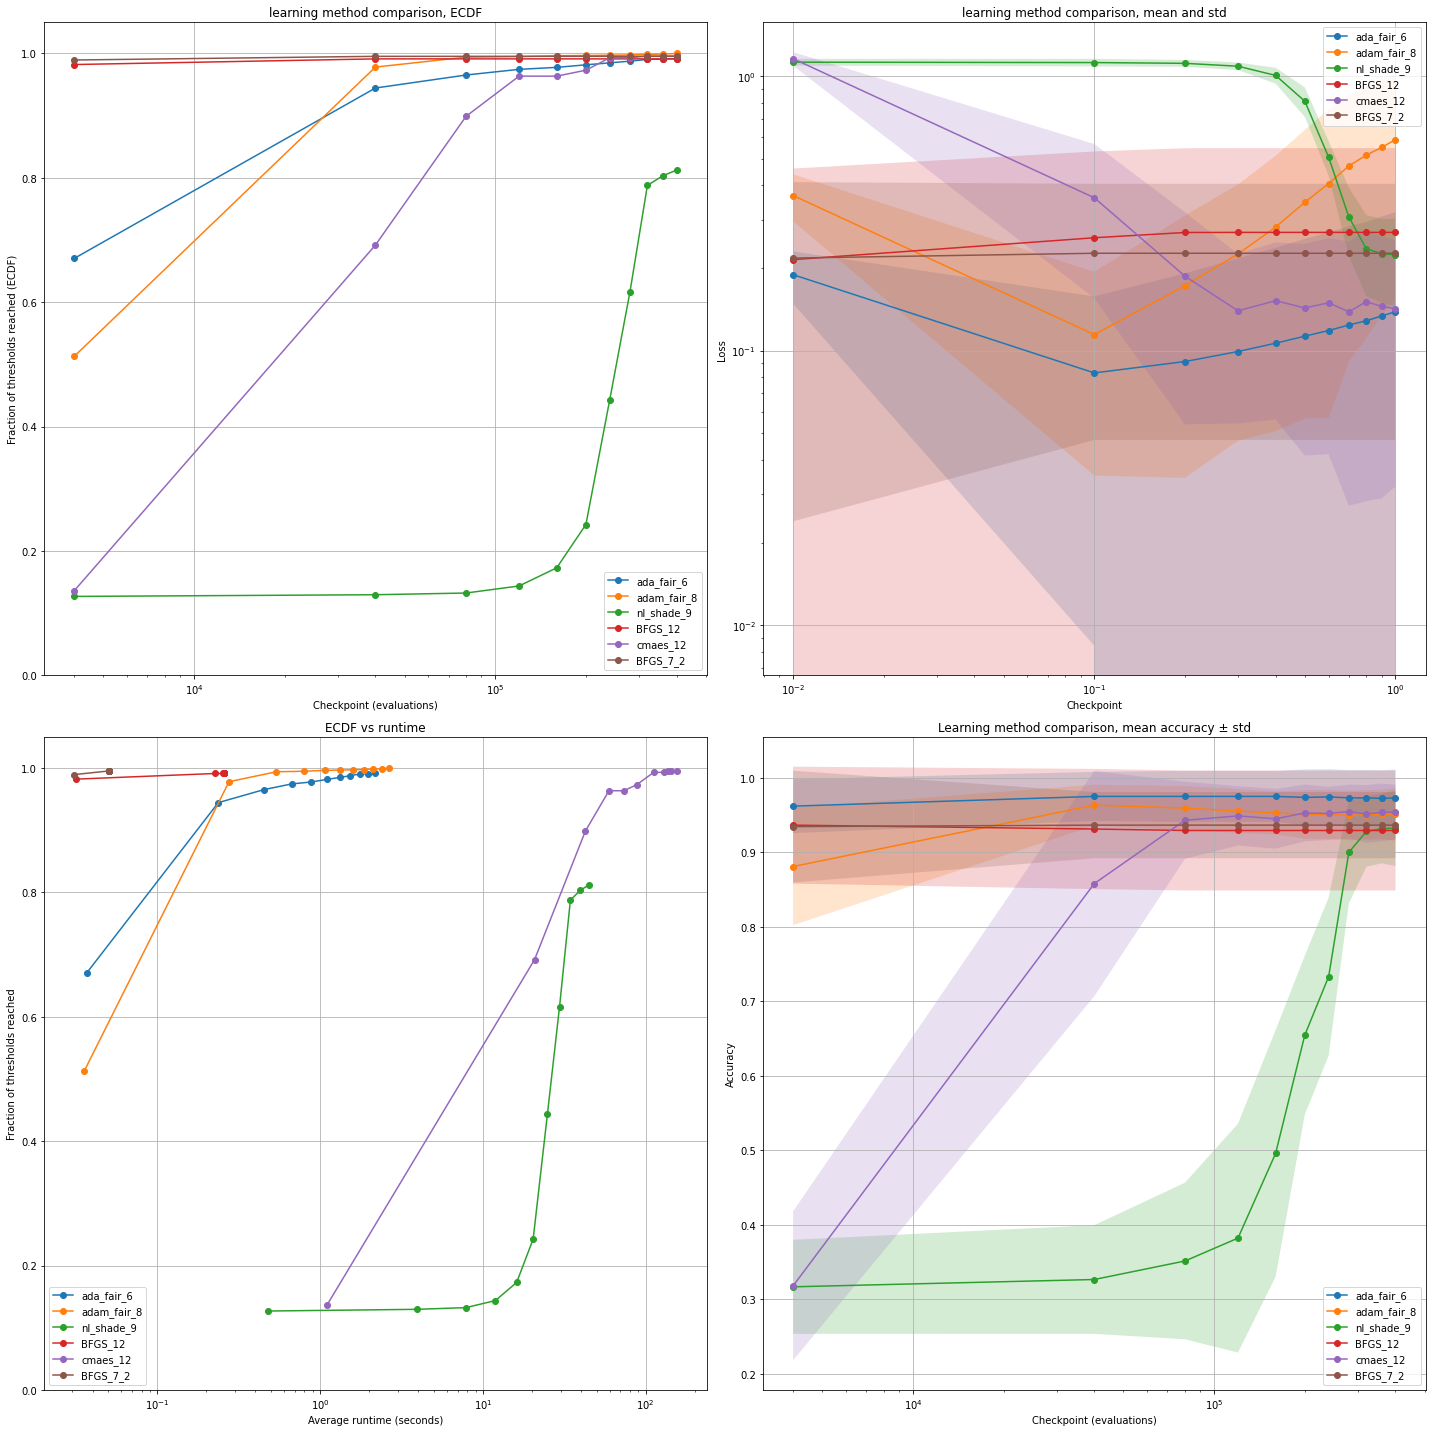

In [23]:
to_compare = []

# indxs = [3, 4, 5, 6, ]
# indxs = [10, 11, 12]
# indxs = [0, 1, 2, 3, 4, 5, 6, -1]

# for i in indxs:
#     to_compare.append(logs[i])

compare(logs)

In [24]:
import scipy
print(scipy.__version__)


1.5.4
